In [13]:
# pip install scikit-learn numpy matplotlib seaborn
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(42)

In [14]:
#Synthetic default (nonlinear cubic with noise). Set USE_CSV=True and provide CSV_PATH, X_COL, Y_COL to use your own.
from pathlib import Path
USE_CSV = False
CSV_PATH = Path('your_data.csv')
X_COL, Y_COL = 'feature_x', 'target_y'

if USE_CSV and CSV_PATH.exists():
    import pandas as pd
    df = pd.read_csv(CSV_PATH)
    X = df[[X_COL]].values.astype(float)
    y = df[Y_COL].values.astype(float)
else:
    N = 200
    X_true = np.linspace(-3, 3, N)
    y_true = 0.5*X_true**3 - 1.2*X_true**2 + 2.0*X_true + 3.0
    y = y_true + np.random.normal(0, 3.0, size=N)
    X = X_true.reshape(-1,1)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [16]:
#Fit models for degrees = 1, 2, 3, 5
degrees = [1, 2, 3, 5]
results = {}
for d in degrees:
    pipe = make_pipeline(PolynomialFeatures(degree=d, include_bias=False), LinearRegression())
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results[d] = {
        'model': pipe,
        'r2':   r2_score(y_test, y_pred),
        'mae':  mean_absolute_error(y_test, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
    }
results

{1: {'model': Pipeline(steps=[('polynomialfeatures',
                   PolynomialFeatures(degree=1, include_bias=False)),
                  ('linearregression', LinearRegression())]),
  'r2': 0.7687762899266836,
  'mae': 4.321542845628147,
  'rmse': np.float64(5.230400922520999)},
 2: {'model': Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(include_bias=False)),
                  ('linearregression', LinearRegression())]),
  'r2': 0.888689724499032,
  'mae': 2.9882783643182256,
  'rmse': np.float64(3.628995469354736)},
 3: {'model': Pipeline(steps=[('polynomialfeatures',
                   PolynomialFeatures(degree=3, include_bias=False)),
                  ('linearregression', LinearRegression())]),
  'r2': 0.9040528076762603,
  'mae': 2.67504090825001,
  'rmse': np.float64(3.3692631532269615)},
 5: {'model': Pipeline(steps=[('polynomialfeatures',
                   PolynomialFeatures(degree=5, include_bias=False)),
                  ('linearregression', LinearRegression()

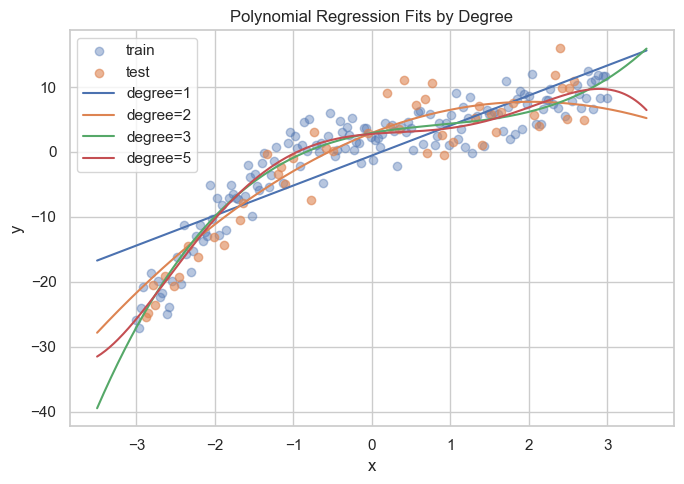

In [17]:
#Visualize fits on one plot
X_plot = np.linspace(X.min()-0.5, X.max()+0.5, 400).reshape(-1,1)
plt.figure(figsize=(7,5))
plt.scatter(X_train, y_train, alpha=0.4, label='train')
plt.scatter(X_test, y_test, alpha=0.6, label='test')
for d in degrees:
    plt.plot(X_plot, results[d]['model'].predict(X_plot), label=f'degree={d}')
plt.title('Polynomial Regression Fits by Degree')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.tight_layout(); plt.show()

In [18]:
#Metrics table (test set)
import pandas as pd
metrics = pd.DataFrame({d: {k:v for k,v in results[d].items() if k!='model'} for d in degrees}).T
metrics.index.name = 'degree'
metrics.sort_values('rmse')

,r2,mae,rmse
degree,,,
3,0.904053,2.675041,3.369263
5,0.903231,2.714629,3.383668
2,0.888690,2.988278,3.628995
1,0.768776,4.321543,5.230401


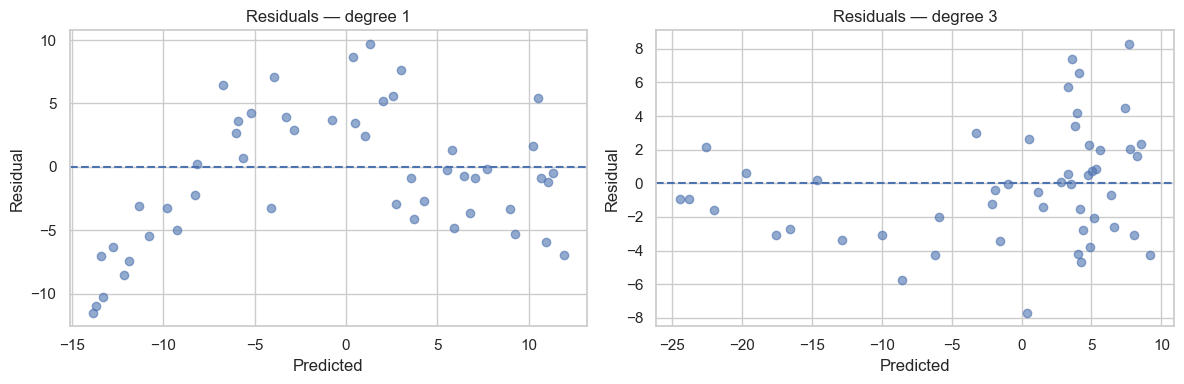

In [19]:
#Residuals vs predicted (spot under/overfit)
choose = [1, 3]
fig, axes = plt.subplots(1, len(choose), figsize=(12,4))
for ax, d in zip(axes, choose):
    mdl = results[d]['model']
    y_pred = mdl.predict(X_test)
    resid = y_test - y_pred
    ax.scatter(y_pred, resid, alpha=0.6)
    ax.axhline(0, linestyle='--')
    ax.set_title(f'Residuals — degree {d}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Residual')
plt.tight_layout(); plt.show()

## Compare degree=5: OLS vs Ridge(alpha=1.0)
Evaluate which model generalizes better on the test set (degree=5 linear model with and without Ridge regularization).

In [ ]:
# Compare degree=5 OLS vs Ridge(alpha=1.0)
np.random.seed(42)
# recreate a standard noisy dataset (sigma=3) for a fair comparison
y_orig = y_true + np.random.normal(0, 3.0, size=N)
X_full = X_true.reshape(-1,1)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_full, y_orig, test_size=0.25, random_state=0)
# OLS degree 5
ols5 = make_pipeline(PolynomialFeatures(5, include_bias=False), LinearRegression()).fit(X_train2, y_train2)
yhat_ols = ols5.predict(X_test2)
# Ridge degree 5 (alpha=1.0)
from sklearn.linear_model import Ridge
ridge5 = make_pipeline(PolynomialFeatures(5, include_bias=False), StandardScaler(with_mean=False), Ridge(alpha=1.0)).fit(X_train2, y_train2)
yhat_ridge = ridge5.predict(X_test2)
# Compute metrics
metrics = {}
metrics['OLS'] = {'r2': r2_score(y_test2, yhat_ols), 'mae': mean_absolute_error(y_test2, yhat_ols), 'rmse': np.sqrt(mean_squared_error(y_test2, yhat_ols))}
metrics['Ridge(alpha=1.0)'] = {'r2': r2_score(y_test2, yhat_ridge), 'mae': mean_absolute_error(y_test2, yhat_ridge), 'rmse': np.sqrt(mean_squared_error(y_test2, yhat_ridge))}
import pandas as pd
df_deg5 = pd.DataFrame(metrics).T
print('Test metrics (degree=5):')
print(df_deg5.round(4))
# Decide which generalizes better by RMSE (lower is better) and R2 (higher is better)
better_rmse = 'Ridge' if df_deg5.loc['Ridge(alpha=1.0)','rmse'] < df_deg5.loc['OLS','rmse'] else 'OLS'
better_r2 = 'Ridge' if df_deg5.loc['Ridge(alpha=1.0)','r2'] > df_deg5.loc['OLS','r2'] else 'OLS'
print(f'
Better by RMSE: {better_rmse}  — Better by R2: {better_r2}')
# Plot predictions vs true
plt.figure(figsize=(8,4))
plt.scatter(X_test2, y_test2, label='test', alpha=0.6)
plt.scatter(X_test2, yhat_ols, label='OLS pred', alpha=0.7)
plt.scatter(X_test2, yhat_ridge, label='Ridge pred', alpha=0.7)
plt.legend(); plt.title('Degree-5: OLS vs Ridge predictions'); plt.tight_layout(); plt.show()
# Residual plots side-by-side
fig, ax = plt.subplots(1,2, figsize=(12,4))
res_ols = y_test2 - yhat_ols
res_ridge = y_test2 - yhat_ridge
ax[0].scatter(yhat_ols, res_ols, alpha=0.6); ax[0].axhline(0,ls='--'); ax[0].set_title('Residuals OLS'); ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('Residual')
ax[1].scatter(yhat_ridge, res_ridge, alpha=0.6); ax[1].axhline(0,ls='--'); ax[1].set_title('Residuals Ridge'); ax[1].set_xlabel('Predicted'); ax[1].set_ylabel('Residual')
plt.tight_layout(); plt.show()

In [ ]:
#(Optional) Choose degree via CV (5‑fold on train)
cv_scores = {}
for d in degrees:
    pipe = make_pipeline(PolynomialFeatures(d, include_bias=False), LinearRegression())
    neg_rmse = cross_val_score(pipe, X_train, y_train, scoring='neg_root_mean_squared_error', cv=5)
    cv_scores[d] = (-neg_rmse.mean(), neg_rmse.std())
best_degree = min(cv_scores, key=lambda d: cv_scores[d][0])
best_degree

5

In [ ]:
#(Optional) Reduce overfitting with Ridge
alphas = [0.0, 0.01, 0.1, 1.0, 10.0]
ridge_scores = []
for a in alphas:
    mdl = make_pipeline(PolynomialFeatures(5, include_bias=False), StandardScaler(with_mean=False), Ridge(alpha=a))
    mdl.fit(X_train, y_train)
    yhat = mdl.predict(X_test)
    ridge_scores.append((a, r2_score(y_test, yhat), np.sqrt(mean_squared_error(y_test, yhat))))
ridge_scores

In [23]:
#Final fit with best_degree'
final_model = make_pipeline(PolynomialFeatures(int(best_degree), include_bias=False), LinearRegression()).fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)
print('Best degree:', best_degree)
print('Test R^2:', round(r2_score(y_test, y_pred_final),3))
print('Test RMSE:', round(np.sqrt(mean_squared_error(y_test, y_pred_final)),3))
print('Test MAE:', round(mean_absolute_error(y_test, y_pred_final),3))

Best degree: 5
Test R^2: 0.903
Test RMSE: 3.384
Test MAE: 2.715


## Increase noise to σ=6 and re-run
Compare degree rankings and residual plots with higher noise (sigma=6).

Metrics with sigma=6:


,r2,mae,rmse
degree,,,
2,0.727439,5.399948,6.728943
3,0.726662,5.350082,6.738526
5,0.724320,5.429258,6.767336
1,0.631055,6.491602,7.828815


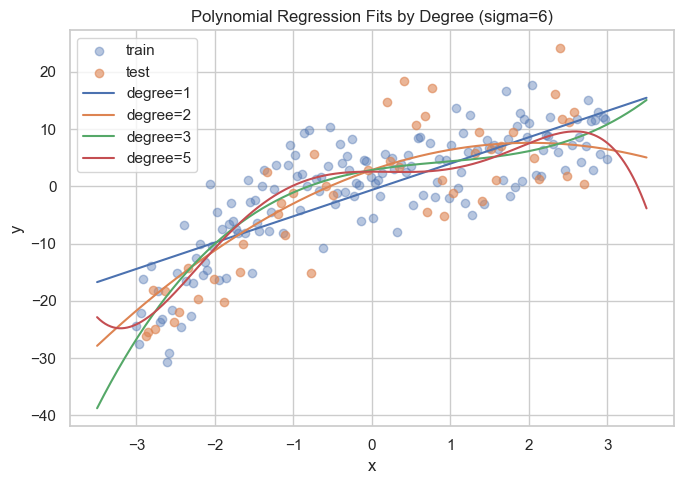

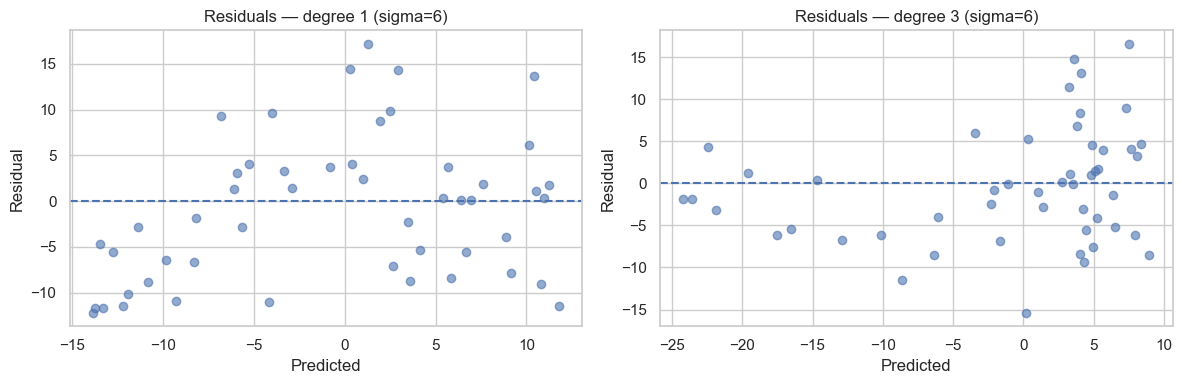

In [24]:
# Increase noise and re-run
sigma = 6.0
np.random.seed(42)
y = y_true + np.random.normal(0, sigma, size=N)
X = X_true.reshape(-1,1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
degrees = [1, 2, 3, 5]
results_noise = {}
for d in degrees:
    pipe = make_pipeline(PolynomialFeatures(degree=d, include_bias=False), LinearRegression())
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results_noise[d] = {
        'model': pipe,
        'r2': r2_score(y_test, y_pred),
        'mae': mean_absolute_error(y_test, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
    }
import pandas as pd
metrics_noise = pd.DataFrame({d: {k:v for k,v in results_noise[d].items() if k!='model'} for d in degrees}).T
metrics_noise.index.name = 'degree'
print('Metrics with sigma=6:')
display(metrics_noise.sort_values('rmse'))

# Plot fits
X_plot = np.linspace(X.min()-0.5, X.max()+0.5, 400).reshape(-1,1)
plt.figure(figsize=(7,5))
plt.scatter(X_train, y_train, alpha=0.4, label='train')
plt.scatter(X_test, y_test, alpha=0.6, label='test')
for d in degrees:
    plt.plot(X_plot, results_noise[d]['model'].predict(X_plot), label=f'degree={d}')
plt.title('Polynomial Regression Fits by Degree (sigma=6)')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.tight_layout(); plt.show()

# Residuals
choose = [1, 3]
fig, axes = plt.subplots(1, len(choose), figsize=(12,4))
for ax, d in zip(axes, choose):
    mdl = results_noise[d]['model']
    y_pred = mdl.predict(X_test)
    resid = y_test - y_pred
    ax.scatter(y_pred, resid, alpha=0.6)
    ax.axhline(0, linestyle='--')
    ax.set_title(f'Residuals — degree {d} (sigma=6)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Residual')
plt.tight_layout(); plt.show()

## Inject 10% outliers (+25) and compare sensitivity
Add +25 to 10% of random y values, re-run models and compare MAE / RMSE / R² sensitivity.

Comparison (clean vs with 10% +25 outliers):


,r2_clean,mae_clean,rmse_clean,r2_out,mae_out,rmse_out,mae_abs_change,rmse_abs_change,r2_abs_change,mae_pct_change,rmse_pct_change,r2_pct_change
2,0.888690,2.988278,3.628995,0.544913,6.047936,9.005017,3.059658,5.376022,0.343777,102.388654,148.140761,38.683553
3,0.904053,2.675041,3.369263,0.574537,5.728178,8.706995,3.053137,5.337732,0.329516,114.134207,158.424318,36.448758
5,0.903231,2.714629,3.383668,0.593694,5.793373,8.508714,3.078744,5.125047,0.309537,113.413052,151.464231,34.269951
1,0.768776,4.321543,5.230401,0.484380,6.959964,9.585224,2.638421,4.354823,0.284396,61.052754,83.259824,36.993394


Average percent change by metric:
  MAE: 97.7%
  RMSE: 135.3%
  R2: 36.6%
Most sensitive metric (average percent change): RMSE


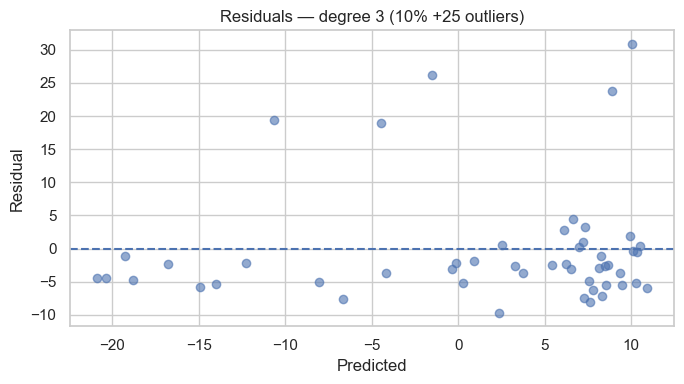

In [27]:
# Inject 10% outliers and compare metrics
np.random.seed(42)
sigma = 3.0  # original noise level
y_clean = y_true + np.random.normal(0, sigma, size=N)
# create outlier version: add +25 to 10% random entries
y_out = y_clean.copy()
n_out = max(1, int(0.10 * N))
out_idx = np.random.choice(N, size=n_out, replace=False)
y_out[out_idx] += 25.0
# helper to compute metrics for degrees
def eval_on(y_vals):
    X_train2, X_test2, y_train2, y_test2 = train_test_split(X_true.reshape(-1,1), y_vals, test_size=0.25, random_state=0)
    res = {}
    for d in degrees:
        pipe = make_pipeline(PolynomialFeatures(d, include_bias=False), LinearRegression())
        pipe.fit(X_train2, y_train2)
        yhat = pipe.predict(X_test2)
        res[d] = {
            'r2': r2_score(y_test2, yhat),
            'mae': mean_absolute_error(y_test2, yhat),
            'rmse': np.sqrt(mean_squared_error(y_test2, yhat)),
        }
    return res, (X_train2, X_test2, y_train2, y_test2)

res_clean, splits_clean = eval_on(y_clean)
res_out, splits_out = eval_on(y_out)

import pandas as pd
df_comp = pd.DataFrame({d: {
    'r2_clean': res_clean[d]['r2'], 'mae_clean': res_clean[d]['mae'], 'rmse_clean': res_clean[d]['rmse'],
    'r2_out': res_out[d]['r2'], 'mae_out': res_out[d]['mae'], 'rmse_out': res_out[d]['rmse']
} for d in degrees}).T
# compute absolute and percent changes
df_comp['mae_abs_change'] = (df_comp['mae_out'] - df_comp['mae_clean']).abs()
df_comp['rmse_abs_change'] = (df_comp['rmse_out'] - df_comp['rmse_clean']).abs()
df_comp['r2_abs_change'] = (df_comp['r2_out'] - df_comp['r2_clean']).abs()
df_comp['mae_pct_change'] = df_comp['mae_abs_change'] / df_comp['mae_clean'] * 100
df_comp['rmse_pct_change'] = df_comp['rmse_abs_change'] / df_comp['rmse_clean'] * 100
df_comp['r2_pct_change'] = df_comp['r2_abs_change'] / df_comp['r2_clean'].replace(0, np.nan) * 100

print('Comparison (clean vs with 10% +25 outliers):')
display(df_comp.sort_values('rmse_abs_change', ascending=False))

# Summary: which metric is most sensitive on average (percent change)
avg_pct = {
    'MAE': df_comp['mae_pct_change'].mean(),
    'RMSE': df_comp['rmse_pct_change'].mean(),
    'R2': df_comp['r2_pct_change'].abs().mean()
}
sens = max(avg_pct, key=avg_pct.get)
print('Average percent change by metric:')
for k,v in avg_pct.items(): print(f'  {k}: {v:.1f}%')
print('Most sensitive metric (average percent change):', sens)

# Plot residuals for degree=3 on outlier data
X_tr, X_te, y_tr, y_te = splits_out
mdl3 = res_out[3]['model'] if 'model' in res_out[3] else make_pipeline(PolynomialFeatures(3, include_bias=False), LinearRegression()).fit(X_tr, y_tr)
# ensure we have a model object: re-fit if needed
if not hasattr(mdl3, 'predict'):
    mdl3 = make_pipeline(PolynomialFeatures(3, include_bias=False), LinearRegression()).fit(X_tr, y_tr)
yhat3 = mdl3.predict(X_te)
resid3 = y_te - yhat3
plt.figure(figsize=(7,4))
plt.scatter(yhat3, resid3, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.title('Residuals — degree 3 (10% +25 outliers)')
plt.xlabel('Predicted'); plt.ylabel('Residual'); plt.tight_layout(); plt.show()

## Learning Curves: degree=3 bias/variance analysis
Use learning_curve to plot training vs cross-validation RMSE as training set size increases. This reveals whether the model suffers from high bias (underfitting) or high variance (overfitting).

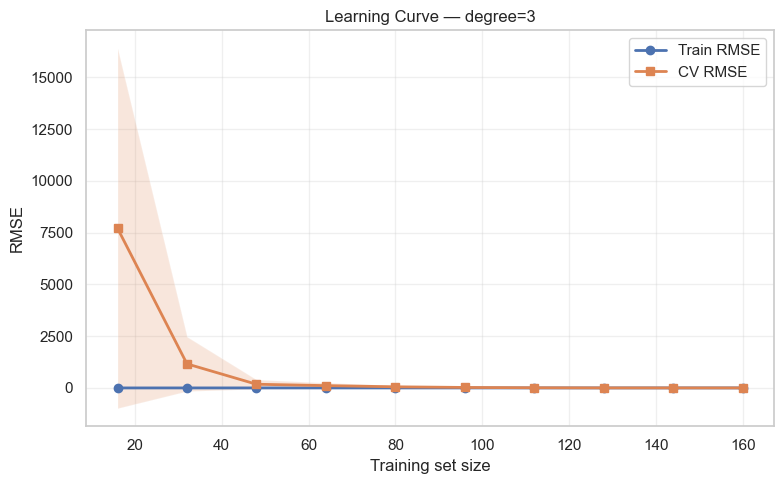

Final training RMSE: 2.761
Final CV RMSE: 2.929
Train-CV gap: 0.168
  ➜ Balanced: Model generalizes well. Training and CV curves are close.


In [28]:
# Learning curve for degree=3
from sklearn.model_selection import learning_curve
# recreate a fresh standard dataset (sigma=3)
np.random.seed(42)
y_fresh = y_true + np.random.normal(0, 3.0, size=N)
X_fresh = X_true.reshape(-1,1)
# define a pipeline for degree=3
pipe_deg3 = make_pipeline(PolynomialFeatures(3, include_bias=False), LinearRegression())
# compute learning curve with varying training set sizes
train_sizes, train_scores, val_scores = learning_curve(
    pipe_deg3, X_fresh, y_fresh, 
    cv=5,
    scoring='neg_root_mean_squared_error',  # returns negative RMSE; negate to get positive
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)
# convert to positive RMSE and compute mean/std
train_rmse_mean = -train_scores.mean(axis=1)
train_rmse_std = train_scores.std(axis=1)
val_rmse_mean = -val_scores.mean(axis=1)
val_rmse_std = val_scores.std(axis=1)
# plot learning curves
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_rmse_mean, 'o-', label='Train RMSE', linewidth=2)
plt.fill_between(train_sizes, train_rmse_mean - train_rmse_std, train_rmse_mean + train_rmse_std, alpha=0.2)
plt.plot(train_sizes, val_rmse_mean, 's-', label='CV RMSE', linewidth=2)
plt.fill_between(train_sizes, val_rmse_mean - val_rmse_std, val_rmse_mean + val_rmse_std, alpha=0.2)
plt.xlabel('Training set size'); plt.ylabel('RMSE'); plt.title('Learning Curve — degree=3')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
# Bias/Variance discussion
final_gap = val_rmse_mean[-1] - train_rmse_mean[-1]
final_val = val_rmse_mean[-1]
print(f'Final training RMSE: {train_rmse_mean[-1]:.3f}')
print(f'Final CV RMSE: {val_rmse_mean[-1]:.3f}')
print(f'Train-CV gap: {final_gap:.3f}')
if final_gap > 0.5:
    print('  ➜ High variance (overfitting): CV RMSE >> Train RMSE. More data or regularization may help.')
elif final_val > 5.0:
    print('  ➜ High bias (underfitting): Both train and CV RMSE are high. Consider more complex model.')
else:
    print('  ➜ Balanced: Model generalizes well. Training and CV curves are close.')